# MVP v0.2.5.4: Score Timestep & Action Scale Sweep

**Date:** 2026-03-13  
**Builds on:** MVP v0.2.5.3 (scorer debug)

## Goal

v0.2.5.3 found that the scorer gradient direction is correct but the magnitude
is catastrophically large due to small sigma at score_timestep=1. This notebook:

1. **Sweep score_timestep** ∈ [1, 2, 5, 10, 20, 50] — find which timestep gives
   best gradient signal (direction test + GD convergence)
2. **Sweep action_scale** with corrected magnitudes [0.0002, 0.0005, 0.001, 0.002, 0.005]
   at the best score_timestep, generating actual trajectories and measuring SR + MSE

## Key numbers from v0.2.5.3

- SOPE sigma[1] = 0.113 (32 steps, linear schedule) → 8.85x amplification
- Our sigma[1] = 0.025 (100 steps, cosine schedule) → 39.8x amplification
- Our sigma[5] = 0.089 → 11.2x amplification (comparable to SOPE)

In [1]:
%matplotlib inline
import sys, os
import importlib
import numpy as np
import torch
import torch.nn as nn
import h5py
import json
import math
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import time

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning

import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = STATE_DIM + ACTION_DIM
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


In [2]:
# ── Load checkpoint & target rollouts ──
ckpt = load_checkpoint(CKPT_DIR, ckpt_path=Path("last.pth"))
target_algo = build_algo_from_checkpoint(ckpt, device=str(device))

target_data = []
rollout_paths = sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]
for path in rollout_paths:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = latents[:, -1, :] if latents.ndim == 3 else latents
    target_data.append({
        "states": states.astype(np.float32),
        "actions": actions.astype(np.float32),
    })
print(f"Loaded {len(target_data)} target rollouts")


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'object', 'robot0_eef_quat', 'robot0_eef_pos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[16:21:08] INFO     build_algo_from_checkpoint took 0.53 seconds to execute                           ]8;id=347720;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=223789;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

Loaded 50 target rollouts


## Part 1: Score Timestep Sweep

For each score_timestep, create a scorer and run:
- **Direction test**: single gradient step from random action, check if it moves closer to real
- **GD convergence**: 100 steps of gradient descent, check convergence rate
- **Magnitude check**: |grad|/|action| ratio

In [3]:
SCORE_TIMESTEPS = [1, 2, 5, 10, 20, 50]
N_TEST = 30
N_GD_PAIRS = 10
N_GD_STEPS = 50
LR_GD = 0.01
LR_DIRECTION = 0.1  # same as v0.2.5.3 Test 2 for comparison

timestep_results = {}

for st in SCORE_TIMESTEPS:
    print(f"\n{'='*60}")
    print(f"score_timestep = {st}")
    print(f"{'='*60}")
    
    # Create scorer at this timestep
    scorer = RobomimicDiffusionScorer(
        target_algo, device=str(device), score_timestep=st, obs_keys=OBS_KEYS
    )
    print(f"  sigma = {scorer.sigma:.6f}, amplification = {1/scorer.sigma:.2f}x")
    
    # ── Direction test (lr=0.1, single step) ──
    np.random.seed(42)
    torch.manual_seed(42)
    closer_count = 0
    grad_norms_real = []
    grad_norms_rand = []
    
    for i in range(N_TEST):
        ep = target_data[i % len(target_data)]
        T = len(ep["states"]) - 1
        t_step = np.random.randint(0, T)
        s = torch.tensor(ep["states"][t_step:t_step+1], device=device)
        a_real = torch.tensor(ep["actions"][t_step:t_step+1], device=device)
        a_rand = torch.randn_like(a_real)
        
        grad_real = scorer.grad_log_prob(s, a_real)
        grad_rand = scorer.grad_log_prob(s, a_rand)
        grad_norms_real.append(grad_real.norm().item())
        grad_norms_rand.append(grad_rand.norm().item())
        
        a_updated = a_rand + LR_DIRECTION * grad_rand
        if (a_updated - a_real).norm().item() < (a_rand - a_real).norm().item():
            closer_count += 1
    
    direction_pct = closer_count / N_TEST * 100
    mean_grad_real = np.mean(grad_norms_real)
    mean_grad_rand = np.mean(grad_norms_rand)
    
    # ── Direction test at SMALL lr (lr=0.01) ──
    np.random.seed(42)
    torch.manual_seed(42)
    closer_small_lr = 0
    for i in range(N_TEST):
        ep = target_data[i % len(target_data)]
        T = len(ep["states"]) - 1
        t_step = np.random.randint(0, T)
        s = torch.tensor(ep["states"][t_step:t_step+1], device=device)
        a_real = torch.tensor(ep["actions"][t_step:t_step+1], device=device)
        a_rand = torch.randn_like(a_real)
        grad_rand = scorer.grad_log_prob(s, a_rand)
        a_updated = a_rand + 0.01 * grad_rand
        if (a_updated - a_real).norm().item() < (a_rand - a_real).norm().item():
            closer_small_lr += 1
    direction_pct_small = closer_small_lr / N_TEST * 100
    
    # ── GD convergence test ──
    np.random.seed(123)
    torch.manual_seed(123)
    gd_converged = 0
    gd_improvements = []
    gd_curves = []
    
    for i in range(N_GD_PAIRS):
        ep = target_data[i % len(target_data)]
        T = len(ep["states"]) - 1
        t_step = T // 2
        s = torch.tensor(ep["states"][t_step:t_step+1], device=device)
        a_real = torch.tensor(ep["actions"][t_step:t_step+1], device=device)
        a_curr = torch.randn_like(a_real)
        
        init_dist = (a_curr - a_real).norm().item()
        dists = [init_dist]
        for step in range(N_GD_STEPS):
            grad = scorer.grad_log_prob(s, a_curr)
            a_curr = a_curr + LR_GD * grad
            dists.append((a_curr - a_real).norm().item())
        
        final_dist = dists[-1]
        gd_curves.append(dists)
        if final_dist < init_dist:
            gd_converged += 1
        gd_improvements.append((init_dist - final_dist) / init_dist)
    
    gd_pct = gd_converged / N_GD_PAIRS * 100
    mean_improvement = np.mean(gd_improvements) * 100
    
    # ── Magnitude check ──
    all_actions = np.concatenate([ep["actions"] for ep in target_data], axis=0)
    mean_action_norm = np.linalg.norm(all_actions, axis=-1).mean()
    grad_action_ratio = mean_grad_real / mean_action_norm
    
    result = {
        "sigma": scorer.sigma,
        "amplification": 1 / scorer.sigma,
        "direction_pct_lr01": direction_pct,
        "direction_pct_lr001": direction_pct_small,
        "grad_norm_real": mean_grad_real,
        "grad_norm_rand": mean_grad_rand,
        "grad_action_ratio": grad_action_ratio,
        "gd_converged_pct": gd_pct,
        "gd_improvement": mean_improvement,
        "gd_curves": np.array(gd_curves),
    }
    timestep_results[st] = result
    
    print(f"  Direction test (lr=0.1):  {direction_pct:.0f}% closer")
    print(f"  Direction test (lr=0.01): {direction_pct_small:.0f}% closer")
    print(f"  |grad| at real: {mean_grad_real:.4f}, at rand: {mean_grad_rand:.4f}")
    print(f"  |grad|/|action| ratio: {grad_action_ratio:.2f}")
    print(f"  GD convergence: {gd_pct:.0f}%, mean improvement: {mean_improvement:.1f}%")


score_timestep = 1
  sigma = 0.041803, amplification = 23.92x


  Direction test (lr=0.1):  10% closer
  Direction test (lr=0.01): 100% closer
  |grad| at real: 14.9543, at rand: 56.6360
  |grad|/|action| ratio: 13.28
  GD convergence: 90%, mean improvement: 60.1%

score_timestep = 2
  sigma = 0.057858, amplification = 17.28x


  Direction test (lr=0.1):  60% closer
  Direction test (lr=0.01): 100% closer
  |grad| at real: 10.2562, at rand: 44.1068
  |grad|/|action| ratio: 9.11
  GD convergence: 100%, mean improvement: 63.3%

score_timestep = 5
  sigma = 0.105039, amplification = 9.52x


  Direction test (lr=0.1):  90% closer
  Direction test (lr=0.01): 100% closer
  |grad| at real: 5.6313, at rand: 27.9840
  |grad|/|action| ratio: 5.00
  GD convergence: 100%, mean improvement: 72.1%

score_timestep = 10
  sigma = 0.182437, amplification = 5.48x


  Direction test (lr=0.1):  100% closer
  Direction test (lr=0.01): 100% closer
  |grad| at real: 3.1721, at rand: 17.4454
  |grad|/|action| ratio: 2.82
  GD convergence: 100%, mean improvement: 72.3%

score_timestep = 20
  sigma = 0.333012, amplification = 3.00x


  Direction test (lr=0.1):  100% closer
  Direction test (lr=0.01): 100% closer
  |grad| at real: 1.4872, at rand: 9.8044
  |grad|/|action| ratio: 1.32
  GD convergence: 100%, mean improvement: 67.1%

score_timestep = 50
  sigma = 0.722313, amplification = 1.38x


  Direction test (lr=0.1):  100% closer
  Direction test (lr=0.01): 100% closer
  |grad| at real: 0.7189, at rand: 3.7638
  |grad|/|action| ratio: 0.64
  GD convergence: 100%, mean improvement: 49.6%


In [4]:
# ── Summary table ──
print(f"\n{'='*100}")
print("SCORE TIMESTEP SWEEP SUMMARY")
print(f"{'='*100}")
print(f"{'t':>4} {'sigma':>8} {'1/sigma':>8} {'dir%@0.1':>9} {'dir%@0.01':>10} {'|grad|_real':>12} {'|grad|/|a|':>11} {'GD conv%':>9} {'GD impr%':>9}")
print("-" * 100)
for st in SCORE_TIMESTEPS:
    r = timestep_results[st]
    print(f"{st:>4} {r['sigma']:>8.4f} {r['amplification']:>8.2f} "
          f"{r['direction_pct_lr01']:>8.0f}% {r['direction_pct_lr001']:>9.0f}% "
          f"{r['grad_norm_real']:>12.4f} {r['grad_action_ratio']:>11.2f} "
          f"{r['gd_converged_pct']:>8.0f}% {r['gd_improvement']:>8.1f}%")

# Find best timestep (highest direction% at small lr + highest GD convergence)
best_st = max(SCORE_TIMESTEPS, key=lambda st: (
    timestep_results[st]["direction_pct_lr001"] + timestep_results[st]["gd_converged_pct"]
))
print(f"\nBest score_timestep: {best_st} "
      f"(dir@0.01={timestep_results[best_st]['direction_pct_lr001']:.0f}%, "
      f"GD={timestep_results[best_st]['gd_converged_pct']:.0f}%)")


SCORE TIMESTEP SWEEP SUMMARY
   t    sigma  1/sigma  dir%@0.1  dir%@0.01  |grad|_real  |grad|/|a|  GD conv%  GD impr%
----------------------------------------------------------------------------------------------------
   1   0.0418    23.92       10%       100%      14.9543       13.28       90%     60.1%
   2   0.0579    17.28       60%       100%      10.2562        9.11      100%     63.3%
   5   0.1050     9.52       90%       100%       5.6313        5.00      100%     72.1%
  10   0.1824     5.48      100%       100%       3.1721        2.82      100%     72.3%
  20   0.3330     3.00      100%       100%       1.4872        1.32      100%     67.1%
  50   0.7223     1.38      100%       100%       0.7189        0.64      100%     49.6%

Best score_timestep: 2 (dir@0.01=100%, GD=100%)


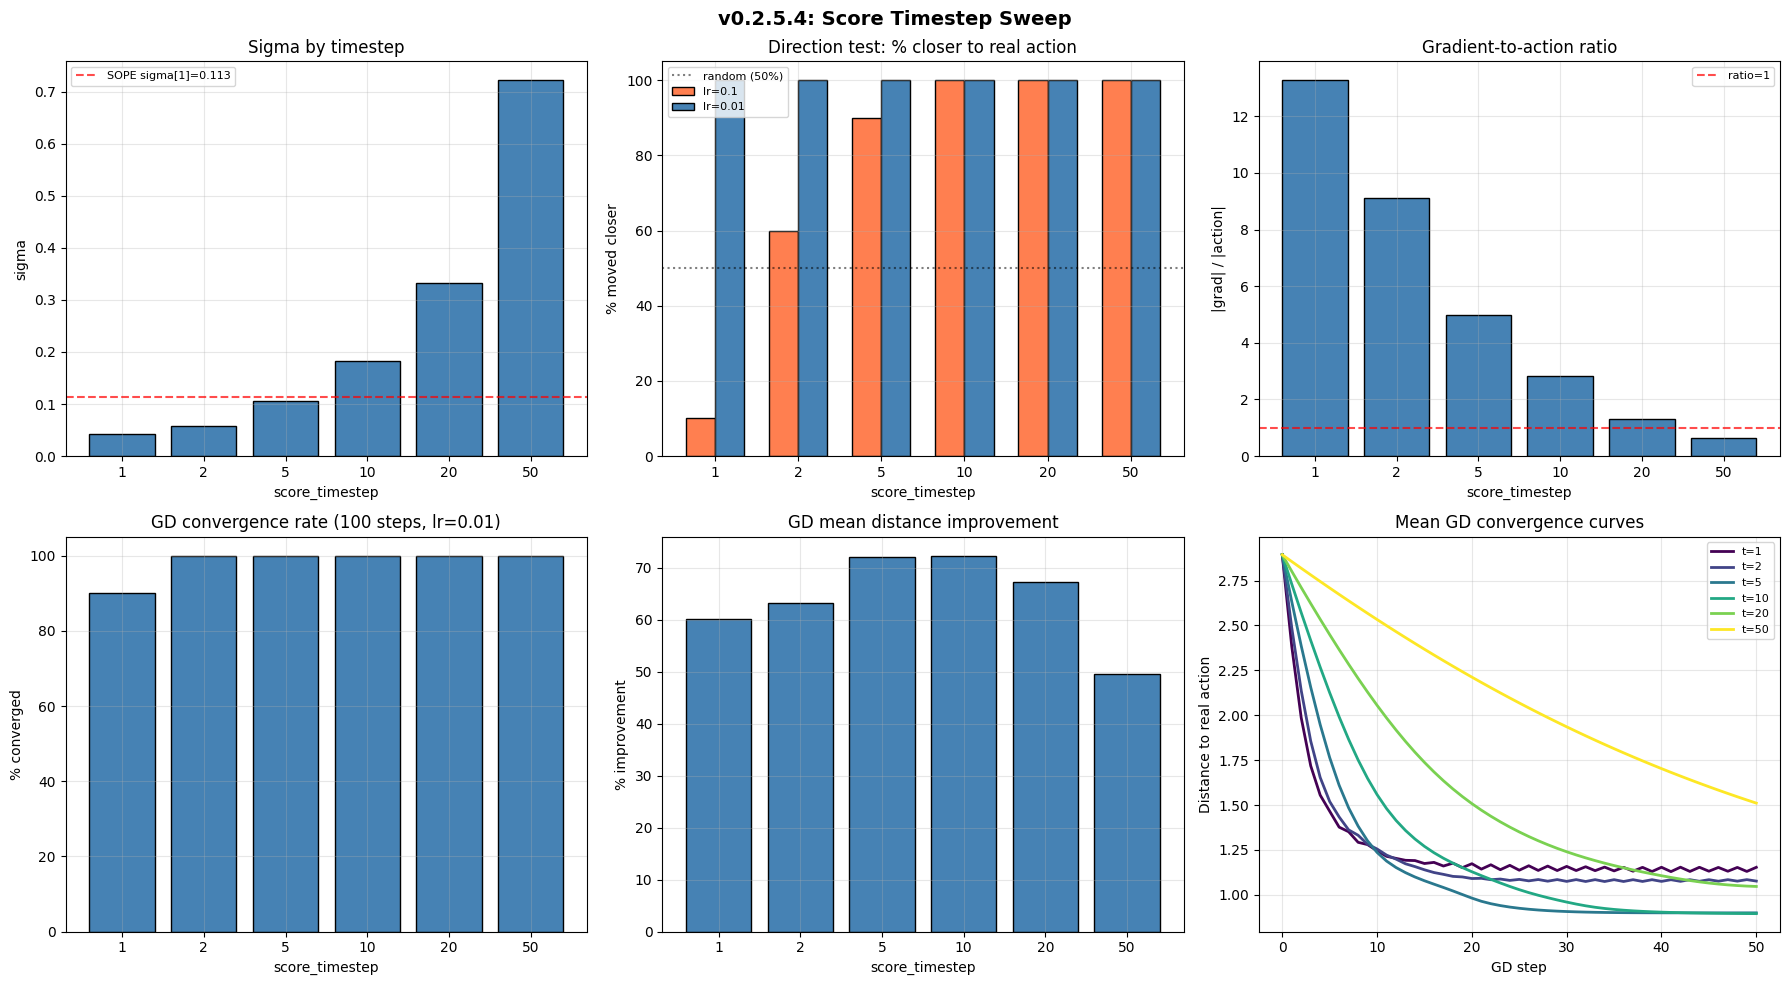

In [5]:
# ── Figure 1: Score timestep sweep visualization ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sts = SCORE_TIMESTEPS
sigmas = [timestep_results[st]["sigma"] for st in sts]
dir_01 = [timestep_results[st]["direction_pct_lr01"] for st in sts]
dir_001 = [timestep_results[st]["direction_pct_lr001"] for st in sts]
grad_ratios = [timestep_results[st]["grad_action_ratio"] for st in sts]
gd_conv = [timestep_results[st]["gd_converged_pct"] for st in sts]
gd_impr = [timestep_results[st]["gd_improvement"] for st in sts]

# Panel 1: sigma and amplification
ax = axes[0, 0]
ax.bar(range(len(sts)), sigmas, color="steelblue", edgecolor="black")
ax.set_xticks(range(len(sts)))
ax.set_xticklabels([str(s) for s in sts])
ax.set_xlabel("score_timestep")
ax.set_ylabel("sigma")
ax.set_title("Sigma by timestep")
ax.axhline(y=0.113, color="red", linestyle="--", alpha=0.7, label="SOPE sigma[1]=0.113")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: direction test both LRs
ax = axes[0, 1]
x = np.arange(len(sts))
w = 0.35
ax.bar(x - w/2, dir_01, w, label="lr=0.1", color="coral", edgecolor="black")
ax.bar(x + w/2, dir_001, w, label="lr=0.01", color="steelblue", edgecolor="black")
ax.axhline(y=50, color="black", linestyle=":", alpha=0.5, label="random (50%)")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in sts])
ax.set_xlabel("score_timestep")
ax.set_ylabel("% moved closer")
ax.set_title("Direction test: % closer to real action")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: |grad|/|action| ratio
ax = axes[0, 2]
ax.bar(range(len(sts)), grad_ratios, color="steelblue", edgecolor="black")
ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="ratio=1")
ax.set_xticks(range(len(sts)))
ax.set_xticklabels([str(s) for s in sts])
ax.set_xlabel("score_timestep")
ax.set_ylabel("|grad| / |action|")
ax.set_title("Gradient-to-action ratio")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: GD convergence %
ax = axes[1, 0]
ax.bar(range(len(sts)), gd_conv, color="steelblue", edgecolor="black")
ax.set_xticks(range(len(sts)))
ax.set_xticklabels([str(s) for s in sts])
ax.set_xlabel("score_timestep")
ax.set_ylabel("% converged")
ax.set_title("GD convergence rate (100 steps, lr=0.01)")
ax.grid(True, alpha=0.3)

# Panel 5: GD improvement %
ax = axes[1, 1]
ax.bar(range(len(sts)), gd_impr, color="steelblue", edgecolor="black")
ax.set_xticks(range(len(sts)))
ax.set_xticklabels([str(s) for s in sts])
ax.set_xlabel("score_timestep")
ax.set_ylabel("% improvement")
ax.set_title("GD mean distance improvement")
ax.grid(True, alpha=0.3)

# Panel 6: GD convergence curves (mean) for each timestep
ax = axes[1, 2]
colors = plt.cm.viridis(np.linspace(0, 1, len(sts)))
for idx, st in enumerate(sts):
    mean_curve = timestep_results[st]["gd_curves"].mean(axis=0)
    ax.plot(mean_curve, color=colors[idx], linewidth=2, label=f"t={st}")
ax.set_xlabel("GD step")
ax.set_ylabel("Distance to real action")
ax.set_title("Mean GD convergence curves")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("v0.2.5.4: Score Timestep Sweep", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Part 2: Guided Trajectory Generation with Corrected Scales

Use the best score_timestep from Part 1 and sweep action_scale
at the corrected (much smaller) values. Generate actual trajectories
and measure SR + MSE.

In [6]:
# ── Load pre-trained diffuser from v0.2.5.2 ──
print("Loading pre-trained diffuser from v0.2.5.2...")

CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0
T_GEN = 30       # trimmed from 60 for faster signal
NUM_SYNTHETIC = 10  # trimmed from 50

# Load expert demos for normalization stats
all_states_list = []
all_actions_list = []
for ep in target_data:
    all_states_list.append(ep["states"])
    all_actions_list.append(ep["actions"])

expert_data = []
with h5py.File(DEMO_HDF5, "r") as f:
    demo_keys = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1]))
    for dk in demo_keys:
        demo = f[f"data/{dk}"]
        obs_arrays = [demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS]
        states = np.concatenate(obs_arrays, axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        expert_data.append({"states": states, "actions": actions})
        all_states_list.append(states)
        all_actions_list.append(actions)

all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

# Build and load diffuser
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)

diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)

ema = EMA(diffusion_model)
ema_state = torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
ema.ema_model.load_state_dict(ema_state)
print(f"Loaded EMA diffuser from {DIFFUSION_SAVE_DIR}")

# Oracle
ORACLE_JSON = CKPT_DIR / "oracle_50.json"
with open(ORACLE_JSON, "r") as f:
    oracle_data = json.load(f)
oracle_value = float(oracle_data["mean_return"])
print(f"Oracle V^pi = {oracle_value:.4f}")

Loading pre-trained diffuser from v0.2.5.2...


[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]
Loaded EMA diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse
Oracle V^pi = 0.5400


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [7]:
# ── Train BC behavior policy (same as v0.2.5.2) ──
class BCGaussian(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.log_std_head = nn.Linear(hidden_dim, action_dim)
    
    def forward(self, state):
        h = self.net(state)
        return self.mean_head(h), self.log_std_head(h).clamp(-5, 2)
    
    def grad_log_prob(self, state, action):
        with torch.no_grad():
            mean, log_std = self.forward(state)
            std = torch.exp(log_std)
            return -(action - mean) / (std ** 2)
    
    def grad_log_prob_chunk(self, states, actions):
        B, T, _ = states.shape
        return self.grad_log_prob(
            states.reshape(B * T, -1), actions.reshape(B * T, -1)
        ).reshape(B, T, -1)

demo_states = np.concatenate([ep["states"][:-1] for ep in target_data], axis=0)
demo_actions = np.concatenate([ep["actions"][:-1] for ep in target_data], axis=0)

bc_behavior = BCGaussian(STATE_DIM, ACTION_DIM).to(device)
bc_optimizer = torch.optim.Adam(bc_behavior.parameters(), lr=1e-3)
states_t = torch.tensor(demo_states, dtype=torch.float32, device=device)
actions_t = torch.tensor(demo_actions, dtype=torch.float32, device=device)

bc_behavior.train()
for epoch in range(500):
    idx = torch.randint(0, len(states_t), (256,), device=device)
    mean, log_std = bc_behavior(states_t[idx])
    std = torch.exp(log_std)
    nll = (0.5 * ((actions_t[idx] - mean) / std) ** 2 + log_std + 0.5 * math.log(2 * math.pi)).sum(-1).mean()
    bc_optimizer.zero_grad()
    nll.backward()
    bc_optimizer.step()
bc_behavior.eval()
print(f"BC behavior policy trained, final NLL: {nll.item():.4f}")

BC behavior policy trained, final NLL: -7.5438


In [8]:
def generate_trajectories_guided(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim,
    chunk_size, t_gen, device,
    target_scorer=None, behavior_scorer=None,
    action_scale=0.0, ratio=0.0,
    normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    use_neg_grad = (behavior_scorer is not None and ratio > 0)
    batch_size = initial_states.shape[0]
    transition_dim = state_dim + action_dim
    n_timesteps = diffusion_model.n_timesteps

    padded = torch.cat([initial_states, torch.zeros(batch_size, action_dim, device=device)], dim=1)
    normalized_initial = normalize_fn(padded)[:, :state_dim]

    all_trajectories = torch.zeros(batch_size, t_gen, transition_dim, device=device)
    conditions = {0: normalized_initial}
    total_generated = 0

    while total_generated < t_gen:
        shape = (batch_size, chunk_size, transition_dim)
        x = torch.randn(shape, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_diff in reversed(range(n_timesteps)):
            t_tensor = torch.full((batch_size,), t_diff, device=device, dtype=torch.long)
            with torch.no_grad():
                model_mean, _, model_log_variance = diffusion_model.p_mean_variance(x=x, t=t_tensor)
                model_std = torch.exp(0.5 * model_log_variance)

            if guided:
                model_mean = unnormalize_fn(model_mean)
                states_chunk = model_mean[:, :, :state_dim]
                actions_chunk = model_mean[:, :, state_dim:]
                target_grad = target_scorer.grad_log_prob_chunk(states_chunk, actions_chunk)
                if use_neg_grad:
                    behavior_grad = behavior_scorer.grad_log_prob_chunk(states_chunk, actions_chunk)
                if normalize_grad:
                    eps = 1e-6
                    target_grad = target_grad / (target_grad.norm(dim=-1, keepdim=True) + eps)
                    if use_neg_grad:
                        behavior_grad = behavior_grad / (behavior_grad.norm(dim=-1, keepdim=True) + eps)
                if use_neg_grad:
                    guide_actions = target_grad - ratio * behavior_grad
                else:
                    guide_actions = target_grad
                guide = torch.zeros_like(model_mean)
                guide[:, :, state_dim:] = guide_actions
                model_mean = model_mean + action_scale * guide
                model_mean = normalize_fn(model_mean)
                model_mean = apply_conditioning(model_mean, conditions, state_dim)
                model_mean = unnormalize_fn(model_mean)
                model_mean = normalize_fn(model_mean)

            noise = torch.randn_like(x)
            nonzero_mask = (1 - (t_diff == 0) * 1.0)
            x = model_mean + nonzero_mask * model_std * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_unnorm = unnormalize_fn(x)
        steps_to_store = min(chunk_size - 1, t_gen - total_generated)
        all_trajectories[:, total_generated:total_generated + steps_to_store] = chunk_unnorm[:, :steps_to_store]
        total_generated += steps_to_store
        if total_generated >= t_gen:
            break
        last_states_norm = x[:, -1, :state_dim]
        conditions = {0: last_states_norm}

    return all_trajectories.detach().cpu().numpy()

print("Trajectory generator ready.")

Trajectory generator ready.


In [9]:
# ── Build real trajectory reference ──
N_COMPARE = min(NUM_SYNTHETIC, len(target_data))
real_trajs = []
for ep in target_data[:N_COMPARE]:
    traj = np.concatenate([ep["states"][:-1], ep["actions"][:-1]], axis=-1)
    T = len(traj)
    if T >= T_GEN:
        real_trajs.append(traj[:T_GEN])
    else:
        padded = np.zeros((T_GEN, TRANSITION_DIM), dtype=np.float32)
        padded[:T] = traj
        padded[T:] = traj[-1]
        real_trajs.append(padded)
real_trajs = np.array(real_trajs)
real_states = real_trajs[:, :, :STATE_DIM]

real_initial_states = np.array([ep["states"][0] for ep in target_data[:N_COMPARE]])
initial_states_t = torch.tensor(real_initial_states, dtype=torch.float32, device=device)

# Only test t=1 (original) and t=5 (SOPE-comparable)
TIMESTEPS_TO_TEST = [1, 5]
ACTION_SCALES = [0.0, 0.0003, 0.001, 0.005, 0.01]

print(f"Trimmed sweep: {N_COMPARE} trajs, T_GEN={T_GEN}")
print(f"score_timesteps={TIMESTEPS_TO_TEST}, action_scales={ACTION_SCALES}")
print(f"Total configs: {1 + len(TIMESTEPS_TO_TEST) * (len(ACTION_SCALES) - 1)}")

Trimmed sweep: 10 trajs, T_GEN=30
score_timesteps=[1, 5], action_scales=[0.0, 0.0003, 0.001, 0.005, 0.01]
Total configs: 9


In [10]:
# ── Run trajectory generation sweep ──
np.random.seed(42)
torch.manual_seed(42)

traj_results = {}

for st in TIMESTEPS_TO_TEST:
    scorer_t = RobomimicDiffusionScorer(
        target_algo, device=str(device), score_timestep=st, obs_keys=OBS_KEYS
    )
    
    for asc in ACTION_SCALES:
        label = f"t{st}_s{asc}"
        is_unguided = (asc == 0.0)
        
        # Skip duplicate unguided runs
        if is_unguided and st != TIMESTEPS_TO_TEST[0]:
            continue
        
        print(f"[t={st}, scale={asc}] ", end="", flush=True)
        t0 = time.time()
        
        trajs = generate_trajectories_guided(
            diffusion_model=ema.ema_model,
            initial_states=initial_states_t,
            normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
            state_dim=STATE_DIM, action_dim=ACTION_DIM,
            chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
            target_scorer=scorer_t if not is_unguided else None,
            behavior_scorer=None,  # pos-only guidance for now
            action_scale=asc, ratio=0.0,
            normalize_grad=True,
        )
        elapsed = time.time() - t0
        
        synth_states = trajs[:, :, :STATE_DIM]
        state_mse = np.mean((real_states - synth_states) ** 2)
        per_step_mse = np.mean((real_states - synth_states) ** 2, axis=(0, 2))
        synth_sr = np.mean([np.any(synth_states[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD) 
                           for j in range(N_COMPARE)])
        
        traj_results[label] = {
            "score_timestep": st,
            "action_scale": asc,
            "state_mse": state_mse,
            "state_rmse": np.sqrt(state_mse),
            "synth_sr": synth_sr,
            "per_step_mse": per_step_mse,
            "synth_states": synth_states,
            "time": elapsed,
        }
        
        print(f"MSE={state_mse:.6f}, SR={synth_sr*100:.0f}%, time={elapsed:.0f}s")

# Summary
print(f"\n{'='*80}")
print("TRAJECTORY GENERATION SWEEP SUMMARY")
print(f"{'='*80}")
print(f"Oracle V^pi = {oracle_value:.4f}")
print(f"\n{'Label':<18} {'t':>3} {'scale':>8} {'State MSE':>10} {'RMSE':>8} {'SR':>6} {'Time':>6}")
print("-" * 65)
for label, r in traj_results.items():
    print(f"{label:<18} {r['score_timestep']:>3} {r['action_scale']:>8.4f} "
          f"{r['state_mse']:>10.6f} {r['state_rmse']:>8.6f} {r['synth_sr']*100:>5.0f}% {r['time']:>5.0f}s")

[t=1, scale=0.0] 

MSE=0.004840, SR=0%, time=27s
[t=1, scale=0.0003] 

MSE=0.004207, SR=0%, time=52s
[t=1, scale=0.001] 

MSE=0.002126, SR=0%, time=52s
[t=1, scale=0.005] 

MSE=0.002314, SR=0%, time=51s
[t=1, scale=0.01] 

MSE=0.002799, SR=0%, time=52s
[t=5, scale=0.0003] 

MSE=0.001939, SR=0%, time=52s
[t=5, scale=0.001] 

MSE=0.002006, SR=0%, time=52s
[t=5, scale=0.005] 

MSE=0.001970, SR=0%, time=51s
[t=5, scale=0.01] 

MSE=0.002773, SR=0%, time=52s

TRAJECTORY GENERATION SWEEP SUMMARY
Oracle V^pi = 0.5400

Label                t    scale  State MSE     RMSE     SR   Time
-----------------------------------------------------------------
t1_s0.0              1   0.0000   0.004840 0.069569     0%    27s
t1_s0.0003           1   0.0003   0.004207 0.064859     0%    52s
t1_s0.001            1   0.0010   0.002126 0.046109     0%    52s
t1_s0.005            1   0.0050   0.002314 0.048101     0%    51s
t1_s0.01             1   0.0100   0.002799 0.052904     0%    52s
t5_s0.0003           5   0.0003   0.001939 0.044032     0%    52s
t5_s0.001            5   0.0010   0.002006 0.044789     0%    52s
t5_s0.005            5   0.0050   0.001970 0.044385     0%    51s
t5_s0.01             5   0.0100   0.002773 0.052658     0%    52s


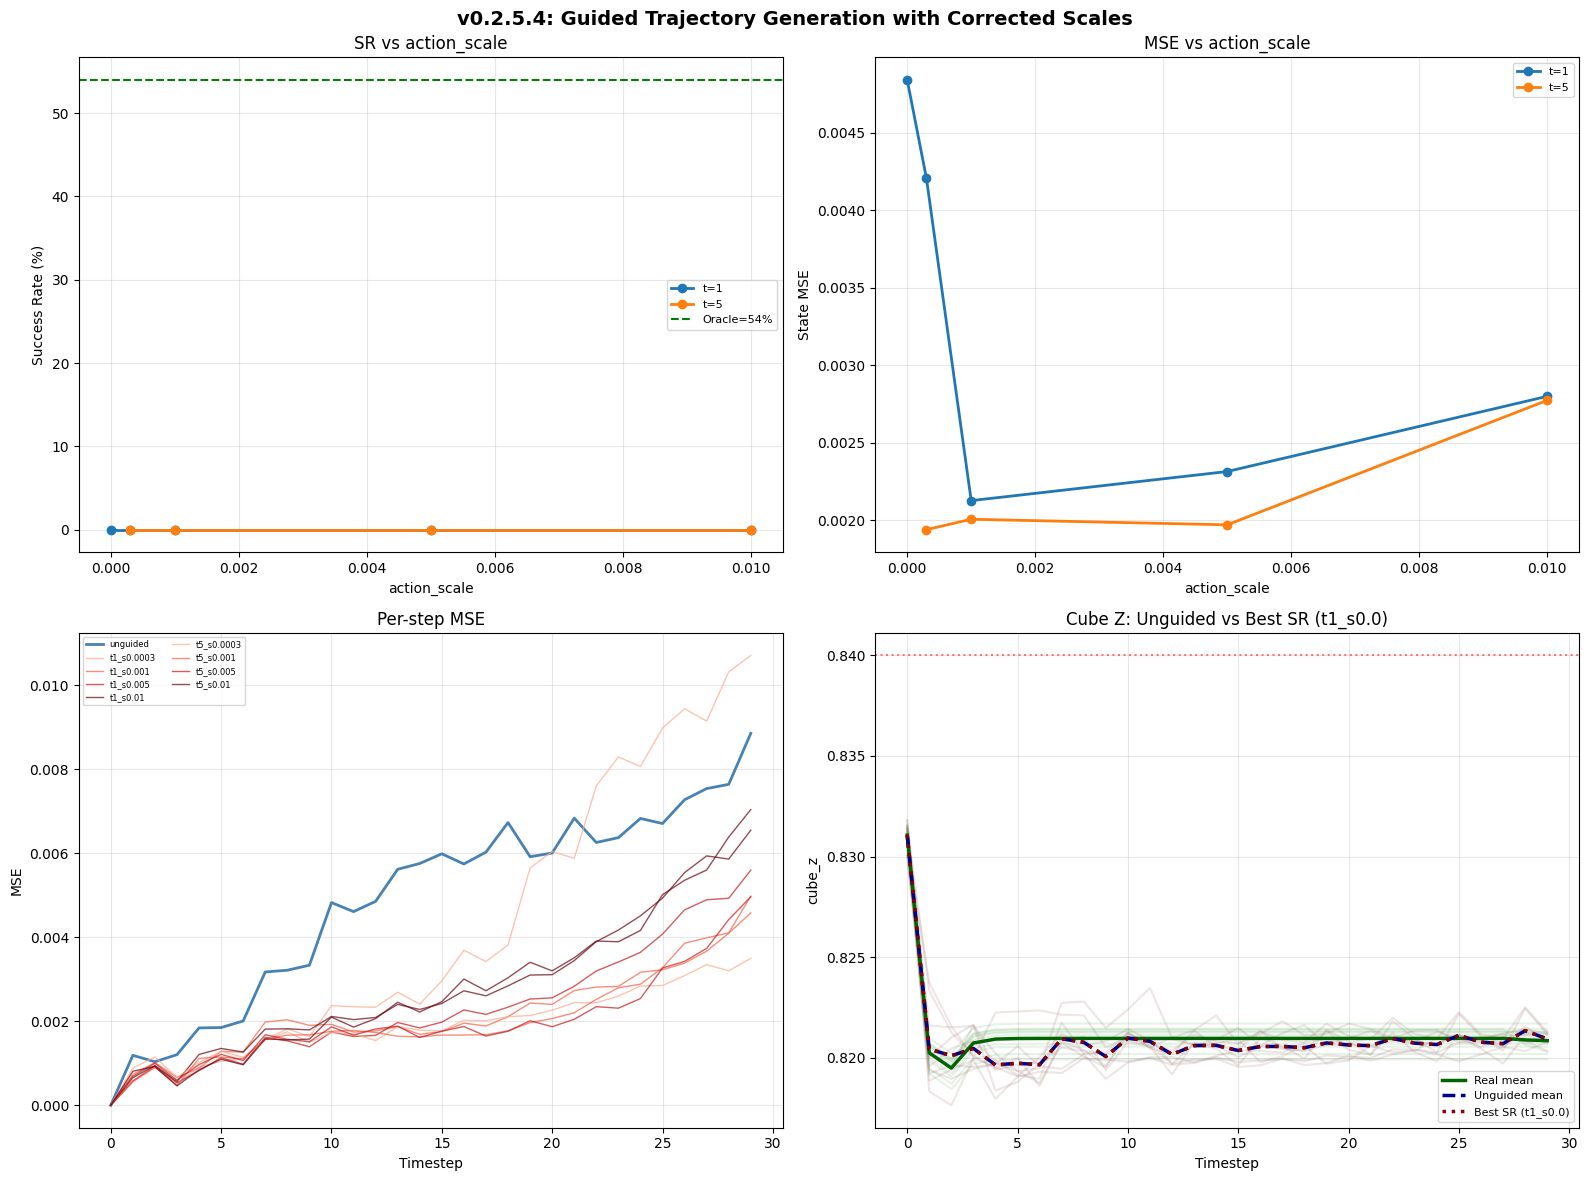

In [11]:
# ── Figure 2: Trajectory generation results ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: SR vs action_scale for each score_timestep
ax = axes[0, 0]
for st in TIMESTEPS_TO_TEST:
    scales = []
    srs = []
    for label, r in traj_results.items():
        if r["score_timestep"] == st or (r["action_scale"] == 0.0 and st == TIMESTEPS_TO_TEST[0]):
            if r["score_timestep"] == st or r["action_scale"] == 0.0:
                scales.append(r["action_scale"])
                srs.append(r["synth_sr"] * 100)
    if scales:
        ax.plot(scales, srs, marker="o", label=f"t={st}", linewidth=2)
ax.axhline(y=oracle_value * 100, color="green", linestyle="--", label=f"Oracle={oracle_value*100:.0f}%")
ax.set_xlabel("action_scale")
ax.set_ylabel("Success Rate (%)")
ax.set_title("SR vs action_scale")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: MSE vs action_scale
ax = axes[0, 1]
for st in TIMESTEPS_TO_TEST:
    scales = []
    mses = []
    for label, r in traj_results.items():
        if r["score_timestep"] == st or (r["action_scale"] == 0.0 and st == TIMESTEPS_TO_TEST[0]):
            if r["score_timestep"] == st or r["action_scale"] == 0.0:
                scales.append(r["action_scale"])
                mses.append(r["state_mse"])
    if scales:
        ax.plot(scales, mses, marker="o", label=f"t={st}", linewidth=2)
ax.set_xlabel("action_scale")
ax.set_ylabel("State MSE")
ax.set_title("MSE vs action_scale")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Per-step MSE for unguided vs best guided
ax = axes[1, 0]
# Find unguided
unguided_label = [l for l, r in traj_results.items() if r["action_scale"] == 0.0][0]
ax.plot(traj_results[unguided_label]["per_step_mse"], label="unguided", linewidth=2, color="steelblue")
# Plot a few guided configs
colors_guided = plt.cm.Reds(np.linspace(0.3, 1.0, len(ACTION_SCALES) - 1))
ci = 0
for label, r in traj_results.items():
    if r["action_scale"] > 0:
        ax.plot(r["per_step_mse"], label=label, linewidth=1, alpha=0.7, color=colors_guided[ci % len(colors_guided)])
        ci += 1
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE")
ax.set_title("Per-step MSE")
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 4: Cube z trajectories — unguided vs best SR config
ax = axes[1, 1]
best_sr_label = max(traj_results, key=lambda l: traj_results[l]["synth_sr"])
for j in range(min(10, N_COMPARE)):
    ax.plot(real_states[j, :, CUBE_Z_INDEX], color="green", alpha=0.1)
    ax.plot(traj_results[unguided_label]["synth_states"][j, :, CUBE_Z_INDEX], color="steelblue", alpha=0.1)
    ax.plot(traj_results[best_sr_label]["synth_states"][j, :, CUBE_Z_INDEX], color="coral", alpha=0.1)
ax.plot(real_states[:, :, CUBE_Z_INDEX].mean(0), color="darkgreen", linewidth=2.5, label="Real mean")
ax.plot(traj_results[unguided_label]["synth_states"][:, :, CUBE_Z_INDEX].mean(0),
        color="darkblue", linewidth=2.5, linestyle="--", label="Unguided mean")
ax.plot(traj_results[best_sr_label]["synth_states"][:, :, CUBE_Z_INDEX].mean(0),
        color="darkred", linewidth=2.5, linestyle=":", label=f"Best SR ({best_sr_label})")
ax.axhline(y=LIFT_THRESHOLD, color="red", linestyle=":", alpha=0.5)
ax.set_xlabel("Timestep")
ax.set_ylabel("cube_z")
ax.set_title(f"Cube Z: Unguided vs Best SR ({best_sr_label})")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("v0.2.5.4: Guided Trajectory Generation with Corrected Scales", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

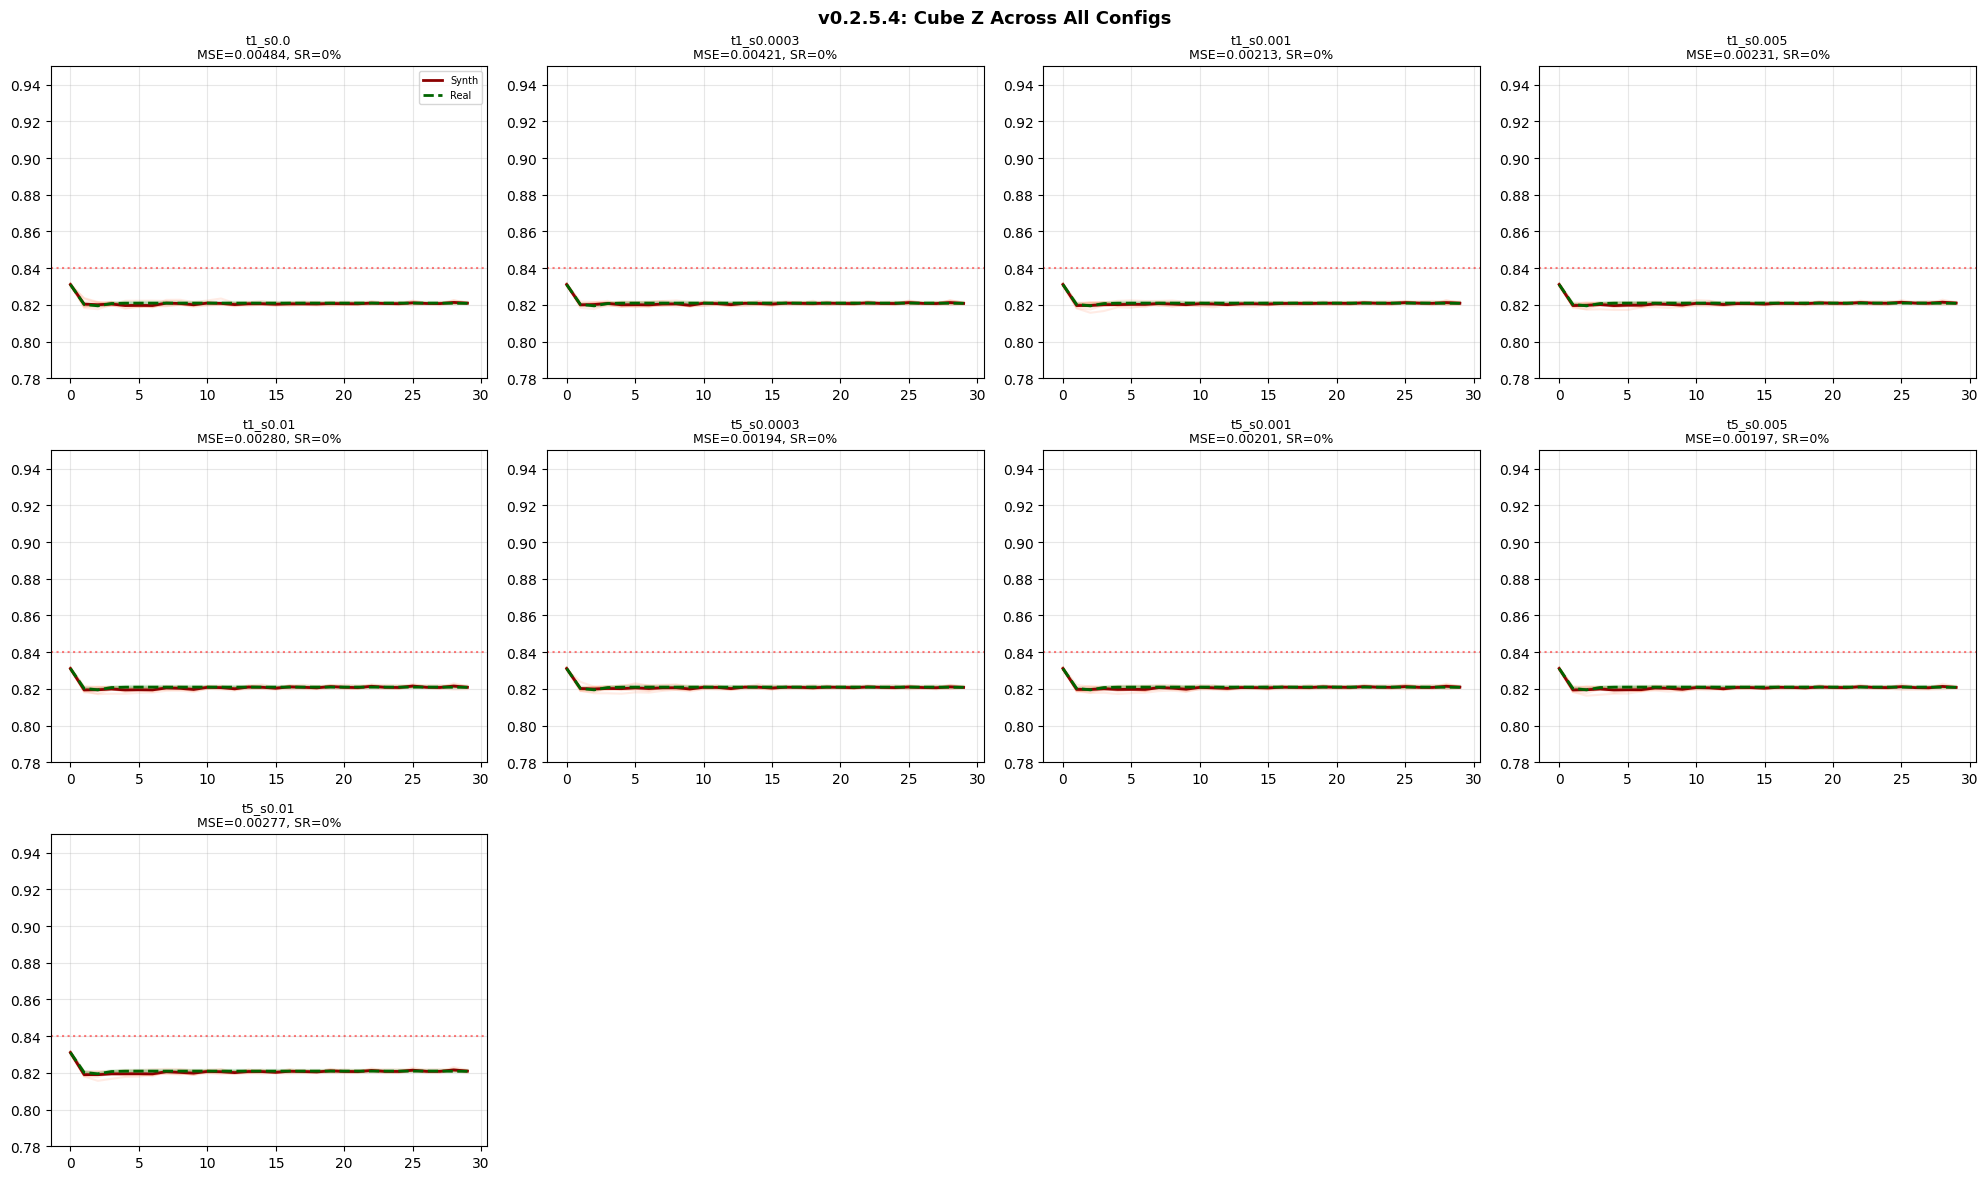

In [12]:
# ── Figure 3: Cube z grid across all configs ──
n_configs = len(traj_results)
n_cols = 4
n_rows = math.ceil(n_configs / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for idx, (label, r) in enumerate(traj_results.items()):
    ax = axes[idx]
    synth_s = r["synth_states"]
    for j in range(min(15, N_COMPARE)):
        ax.plot(synth_s[j, :, CUBE_Z_INDEX], color="coral", alpha=0.15)
    for j in range(min(5, N_COMPARE)):
        ax.plot(real_states[j, :, CUBE_Z_INDEX], color="green", alpha=0.1)
    ax.plot(synth_s[:, :, CUBE_Z_INDEX].mean(0), color="darkred", linewidth=2, label="Synth")
    ax.plot(real_states[:, :, CUBE_Z_INDEX].mean(0), color="darkgreen", linewidth=2, linestyle="--", label="Real")
    ax.axhline(y=LIFT_THRESHOLD, color="red", linestyle=":", alpha=0.5)
    ax.set_title(f"{label}\nMSE={r['state_mse']:.5f}, SR={r['synth_sr']*100:.0f}%", fontsize=9)
    ax.set_ylim([0.78, 0.95])
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

for idx in range(n_configs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("v0.2.5.4: Cube Z Across All Configs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

In [13]:
print("=" * 70)
print("MVP v0.2.5.4 COMPLETE")
print("=" * 70)

print(f"\n--- Part 1: Score Timestep Sweep ---")
print(f"Best score_timestep: {best_st}")
print(f"  sigma={timestep_results[best_st]['sigma']:.4f}, "
      f"amplification={timestep_results[best_st]['amplification']:.1f}x")
print(f"  Direction@0.01: {timestep_results[best_st]['direction_pct_lr001']:.0f}%")
print(f"  GD convergence: {timestep_results[best_st]['gd_converged_pct']:.0f}%")
print(f"  |grad|/|action|: {timestep_results[best_st]['grad_action_ratio']:.2f}")

print(f"\n--- Part 2: Trajectory Generation ---")
print(f"Oracle V^pi = {oracle_value:.4f}")

# Find best configs
closest_sr_label = min(traj_results, key=lambda l: abs(traj_results[l]["synth_sr"] - oracle_value))
best_mse_guided = min(
    (l for l, r in traj_results.items() if r["action_scale"] > 0),
    key=lambda l: traj_results[l]["state_mse"]
)

print(f"\nClosest to oracle SR: {closest_sr_label}")
print(f"  SR={traj_results[closest_sr_label]['synth_sr']*100:.0f}%, "
      f"MSE={traj_results[closest_sr_label]['state_mse']:.6f}")

print(f"\nBest guided MSE: {best_mse_guided}")
print(f"  SR={traj_results[best_mse_guided]['synth_sr']*100:.0f}%, "
      f"MSE={traj_results[best_mse_guided]['state_mse']:.6f}")

print(f"\nUnguided baseline:")
print(f"  SR={traj_results[unguided_label]['synth_sr']*100:.0f}%, "
      f"MSE={traj_results[unguided_label]['state_mse']:.6f}")

print(f"\n--- Diagnosis ---")
ug_sr = traj_results[unguided_label]["synth_sr"]
best_guided_sr = traj_results[closest_sr_label]["synth_sr"]
if abs(best_guided_sr - oracle_value) < abs(ug_sr - oracle_value):
    print("Guidance IMPROVED SR toward oracle compared to unguided.")
else:
    print("Guidance did NOT improve SR toward oracle compared to unguided.")
    print("May need: different score_timestep, rollout bug fix, or neg-grad tuning.")

MVP v0.2.5.4 COMPLETE

--- Part 1: Score Timestep Sweep ---
Best score_timestep: 2
  sigma=0.0579, amplification=17.3x
  Direction@0.01: 100%
  GD convergence: 100%
  |grad|/|action|: 9.11

--- Part 2: Trajectory Generation ---
Oracle V^pi = 0.5400

Closest to oracle SR: t1_s0.0
  SR=0%, MSE=0.004840

Best guided MSE: t5_s0.0003
  SR=0%, MSE=0.001939

Unguided baseline:
  SR=0%, MSE=0.004840

--- Diagnosis ---
Guidance did NOT improve SR toward oracle compared to unguided.
May need: different score_timestep, rollout bug fix, or neg-grad tuning.
